# Gradient Descent

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Minimize f(x) = (x - 3)²
# True minimum is at x = 3

def f(x):
    return (x - 3)**2
def df(x):
    return 2*(x - 3)  

In [4]:
# gradient descent loop
x = 10.0          # start far from minimum
lr = 0.1          # learning rate
history = [x]

for step in range(50):
    gradient = df(x)
    x = x - lr * gradient     # moving opposite to gradient
    history.append(x)

print(f"Final x: {x:.6f}  (true minimum: 3.0)")

Final x: 3.000100  (true minimum: 3.0)


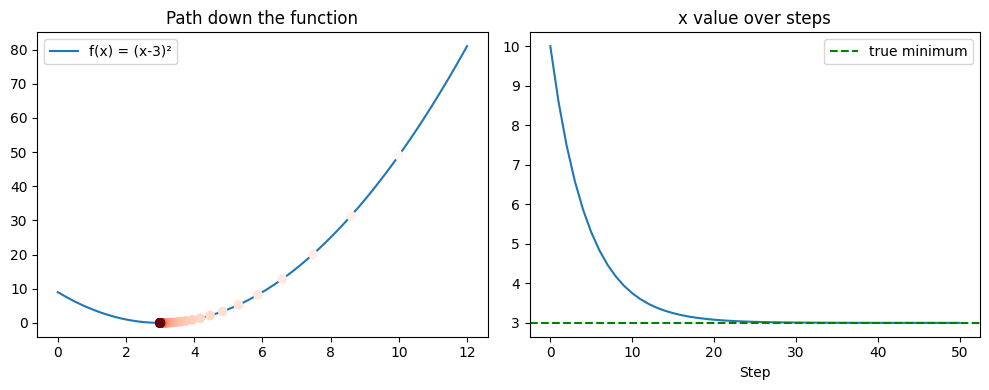

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
x_plot = np.linspace(0, 12, 200)
plt.plot(x_plot, (x_plot-3)**2, label='f(x) = (x-3)²')
plt.scatter(history, [(h-3)**2 for h in history], 
            c=range(len(history)), cmap='Reds', zorder=5)
plt.title('Path down the function')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history)
plt.axhline(3, color='green', linestyle='--', label='true minimum')
plt.title('x value over steps')
plt.xlabel('Step')
plt.legend()
plt.tight_layout()
plt.show()

### Learning rate effect

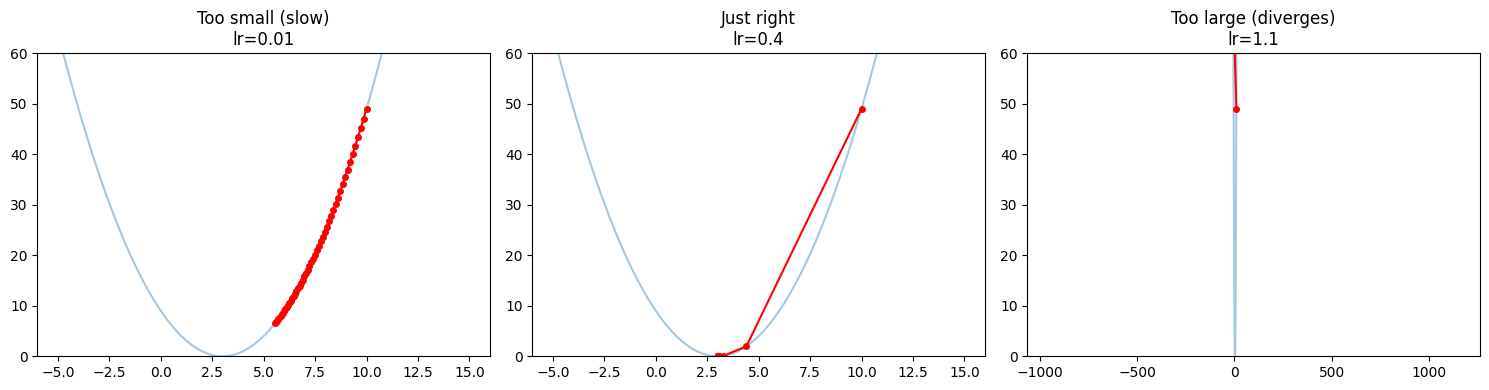

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
learning_rates = [0.01, 0.4, 1.1]
titles = ['Too small (slow)', 'Just right', 'Too large (diverges)']

for ax, lr, title in zip(axes, learning_rates, titles):
    x = 10.0
    history = [x]
    for _ in range(50):
        x = x - lr * 2*(x-3)
        history.append(x)
        if abs(x) > 1000:   # stop if diverged
            break
    
    x_plot = np.linspace(-5, 15, 200)
    ax.plot(x_plot, (x_plot-3)**2, alpha=0.4)
    ax.plot(history, [(h-3)**2 if abs(h)<100 else 100 
                      for h in history], 'ro-', markersize=4)
    ax.set_title(f'{title}\nlr={lr}')
    ax.set_ylim(0, 60)

plt.tight_layout()
plt.show()

Learning rate controls step size.
Too small → takes forever to converge.
Too large → overshoots and diverges (loss goes up, not down).
Just right → converges smoothly in reasonable steps.

This is the most important hyperparameter in any ML model.
In practice: start with 0.01, watch the loss curve, adjust.


### Gradient Descent in 2D

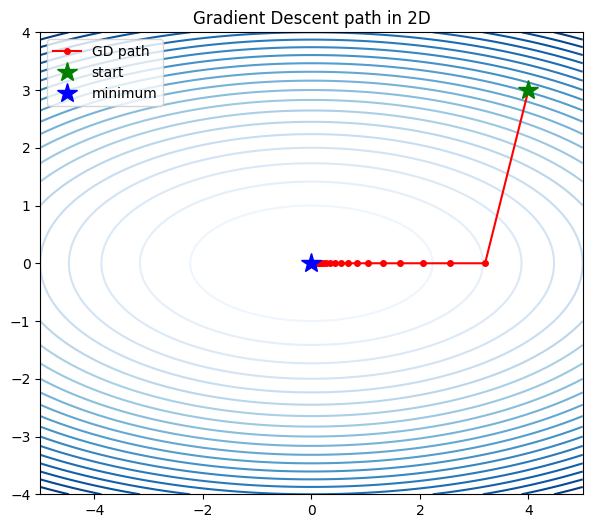

In [11]:
# f(x,y) = x² + 5y²
# bowl shaped but stretched — gradient descent path is interesting

def f2d(x, y): 
    return x**2 + 5*y**2
def grad_f2d(x, y):
    return np.array([2*x, 10*y])

x, y = 4.0, 3.0
lr = 0.1
path = [(x, y)]

for _ in range(50):
    gx, gy = grad_f2d(x, y)
    x -= lr * gx
    y -= lr * gy
    path.append((x, y))

path = np.array(path)

# contour plot with path
x_grid = np.linspace(-5, 5, 100)
y_grid = np.linspace(-4, 4, 100)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
Z = X_g**2 + 5*Y_g**2

plt.figure(figsize=(7, 6))
plt.contour(X_g, Y_g, Z, levels=20, cmap='Blues')
plt.plot(path[:, 0], path[:, 1], 'ro-', markersize=4, label='GD path')
plt.plot(path[0, 0], path[0, 1], 'g*', markersize=15, label='start')
plt.plot(0, 0, 'b*', markersize=15, label='minimum')
plt.title('Gradient Descent path in 2D')
plt.legend()
plt.show()